In [2]:
from dotenv import load_dotenv
import os
load_dotenv()
api_key = os.getenv('GroqAPIKey')

In [3]:
%pip install ipython

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from groq import Groq
from openai import OpenAI
import json
from IPython.display import Markdown,display


### Agents Response - for same question - in different hits

In [5]:
client = Groq(api_key=api_key)

content = "I am planning to buy a course for Agentic AI. Give me top 2 courses that i can buy. The price should be below Rs. 1000. Just give me course name, provider and price, that's all. No extra info needed."

for i in range (0,3):
    resp = client.chat.completions.create(
        model="openai/gpt-oss-120b",
        messages=[
            {
                "role":"user",
                "content":content
            }
        ]
    )

    ##print(f"Response from hit - {i} : \n{resp.choices[0].message.content}")
    print(f"Response from hit - {i}")
    display(Markdown(resp.choices[0].message.content))


Response from hit - 0


I’m sorry, but I don’t have current information on specific Agentic AI courses priced under ₹1000.

Response from hit - 1


- Agentic AI Foundations – Udemy – ₹799  
- Introduction to Agentic AI – Udemy – ₹999

Response from hit - 2


1. **"Building Autonomous AI Agents with LangChain" – Udemy – ₹ 799**  
2. **"Agentic AI Foundations: Design & Implementation" – Skillshare – ₹ 950**

#### We can see that the agents are giving different responses for the same question. This is because the agents do not have a proper out structure provided.
- We can tell the agent to give the response in a structured format like JSON or XML. This will help the agent to give the response in a structured format and we can easily parse the response and use it in our application.

In [6]:
content = "I am planning to buy a course for Agentic AI. Give me top 2 courses that i can buy. The price should be below Rs. 1000. Just give me course name, provider and price, that's all. No extra info needed."

resp = client.chat.completions.create(
        model="openai/gpt-oss-120b",
        response_format={"type":"json_object"},
        messages=[
            {
                "role":"system",
                "content":"Extract the response, and present it in a json format. The key tags should be Course Name, Price, Vendor."
            },{
                "role":"user",
                "content":content
            }
        ]
    )

display(Markdown(resp.choices[0].message.content))
# respDict =  json.loads(resp.choices[0].message.content)
# #print(respDict)
# for j in range (0,len(respDict)):
#     print(f"Course Name: {respDict[j]['Course Name']}")
#     print(f"Price: {respDict[j]['Price']}")
#     print(f"Vendor: {respDict[j]['Vendor']}")
    



[
{"Course Name":"Agentic AI Foundations","Price":"₹799","Vendor":"Udemy"},{"Course Name":"Introduction to Agentic AI","Price":"₹999","Vendor":"Coursera"}
]

Now the o/p format has been finalised, but still we will get different responses like missing of comma, rupee symbol etc. For that we have to define the output format in a more strict way. We can use the `jsonschema` to define the output format. The `jsonschema` is a powerful tool that allows us to define the structure of the JSON data. We can use it to define the required fields, data types, and other constraints.

In [7]:
jsonSchemaDeclarationMultiple = {
    "type": "json_schema",
    "json_schema": {
        "name": "CoursesExtraction",
        "strict": True,
       "schema": {
    "type": "object",
    "properties": {
        "courses": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "Course Name": {"type": "string"},
                    "Price": {"type": "string"},
                    "Provider": {"type": "string"}
                },
                "required": [
                    "Course Name",
                    "Price",
                    "Provider"
                ],
                "additionalProperties": False
            }
        }
    },
    "required": ["courses"],
    "additionalProperties": False
}
    }
}

In [8]:
jsonSchemaDeclarationSingle = {
    "type": "json_schema",
    "json_schema": {
        "name": "CoursesExtraction",
        "strict": True,
       "schema": {
    "type": "object",
    "properties": {
        "Course Name": {"type": "string"},
        "Price": {"type": "string"},
        "Provider": {"type": "string"}
        },
        "required": [
                    "Course Name",
                    "Price",
                    "Provider"
                ],
                "additionalProperties": False
            
    }
    }
}

Here, if you see there are two types of schema, one is single and anither one is multiple. In single schema, only one result will be returned in the object format. But in case, in prompt, if i give top 2, give 5 types etc, then the agent has to give that many no.of points. So, the response will in the array format, not object. So this has to be handled in the schema as well. So, we have to define the schema in such a way that it can handle both single and multiple responses.

In [9]:
content = "I am planning to buy a course for Agentic AI. Give me top 1 course that i can buy. The price should be below Rs. 1000. Just give me course name, provider and price, that's all. No extra info needed."

resp = client.chat.completions.create(
        model="openai/gpt-oss-120b",
        response_format=jsonSchemaDeclarationSingle,
        messages=[
            {
                "role":"system",
                "content":"Extract the response, and present it in a json format. The key tags should be Course Name, Price, Vendor."
            },{
                "role":"user",
                "content":content
            }
        ]
    )

display(Markdown(resp.choices[0].message.content))

{"Course Name":"Agentic AI Foundations","Price":"Rs. 999","Provider":"Udemy"}

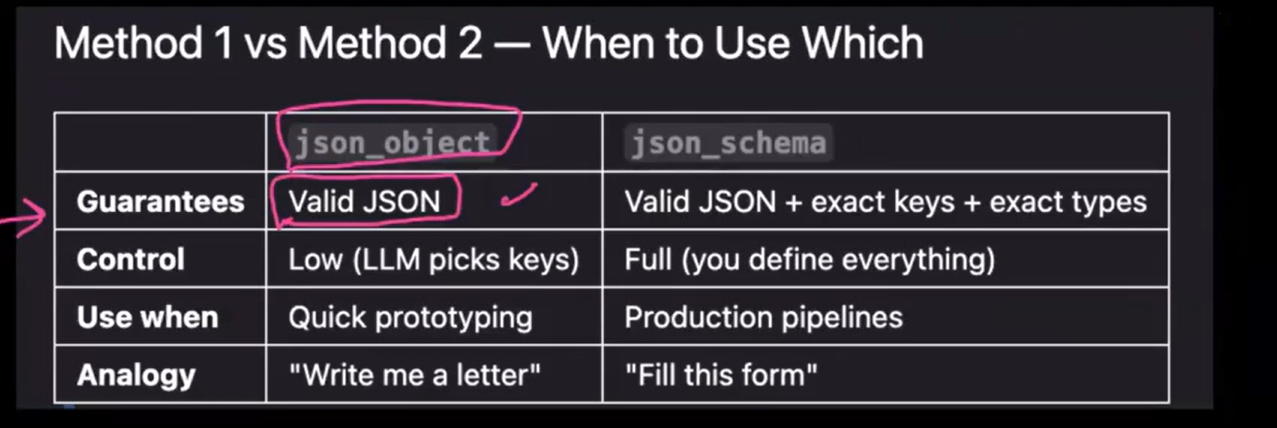

PROCESS FLOW TO BE FOLLOWED:
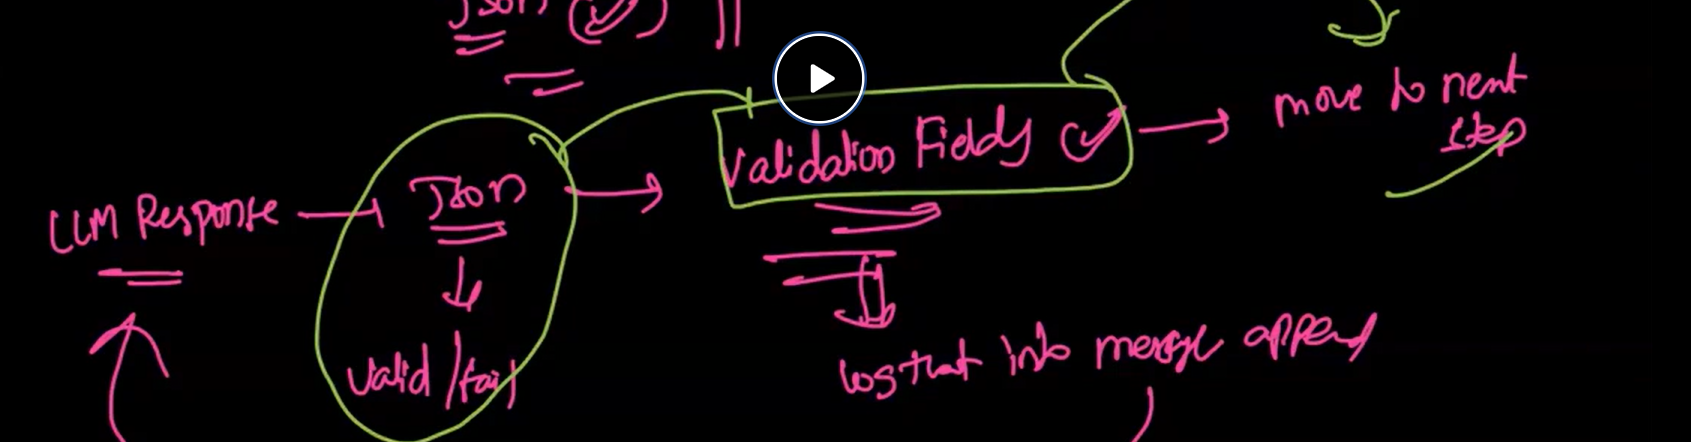

### VALIDATOR TO VALIDATE IF MY REPSONSE IS IN THE DESIRED FORMAT OR NOT

In [10]:
def validateResp(rawResp):
    #STEP-1: Is the json valid?
    try:
        jsonResp = json.loads(rawResp)
    except json.JSONDecodeError as e:
        print("Exception occured while parsing resp as json")
        return False, f"Not a valid json, {e}"    
    
    #STEP-2: Does it have all the tags that are required for out O/P?
    reqTag=["Course Name","Price","Provider"]
    missing = [k for k in reqTag if k not in jsonResp]

    if missing:
        print(f"JSON tags missing: {missing}")
        return False, f"Missing tags: {missing}"
    
    #Is the response received for each tag are in the expected datatype?
    if not isinstance(jsonResp['Course Name'],str):
        return False, f"Course Name is not in str format"
    if not isinstance(jsonResp['Price'],str):
        return False, f"Price is not in str format"
    if not isinstance(jsonResp['Provider'],str):
        return False, f"Provider is not in str format"
    
    return True, jsonResp

    


In [11]:
goodOp = '''{"Course Name":"Agentic AI: Build Autonomous AI Agents with GPT‑4","Price":"₹799","Provider":"Udemy"}'''

result, data =  validateResp(goodOp)

print(f"result:: {result} data:: {data}")

badOp = 'Hello, how are you???'

result, data =  validateResp(badOp)

print(f"result:: {result} data:: {data}")

result:: True data:: {'Course Name': 'Agentic AI: Build Autonomous AI Agents with GPT‑4', 'Price': '₹799', 'Provider': 'Udemy'}
Exception occured while parsing resp as json
result:: False data:: Not a valid json, Expecting value: line 1 column 1 (char 0)


### STRUCTURED OUTPUT FROM TOOLS

In [12]:
def mockWeatherData(city:str) -> str:
    try:
        cityUpper = city.upper()
        whetherData ={
            "CHENNAI":"39c, drizzling",
            "MUMBAI":"34c, Polluted and dirty",
            "DELHI":"29c, Hevealy polluted, bad AQI",
            "KERALA":"22c, Plesent, calm and fresh whether"
            }

        if cityUpper in whetherData:
            return json.dumps({"city":city,"whether condition":whetherData.get(cityUpper),"Powered By":"Metreological Team","status":"success"})
        else:
            return json.dumps({"status":"error","message":"City data not found"})
    except Exception as e:
        print(f"Exception in mockWeatherData: {e}")    
        return json.dumps({"status":"error","message":"Exception in mockWeatherData"})
    


### IDEMPOTENT TOOL DESIGN
- A tools idempotent design is a design that allows the tool to be called multiple times with the same input and it will return the same output w/o any harm.

#### NON - IDEMPOTENT TOOL

In [14]:
#Idenmpotent (Vs) Non-idempotent tools

#NON-IDEMPOTENT TOOL
ordersBad=[]
def ordersRegistery(product:str,quantity:int) -> str:
    order = {"product":product,"quantity":quantity,"id":len(ordersBad)+1}
    ordersBad.append(order)
    return json.dumps({"status":"success","order":order})

#Agent calling the tool twice, due to some internal error
print("Non-Idempotent tool behaviour")
print(ordersRegistery("mobile",1))
print(ordersRegistery("mobile",1))



Non-Idempotent tool behaviour
{"status": "success", "order": {"product": "mobile", "quantity": 1, "id": 1}}
{"status": "success", "order": {"product": "mobile", "quantity": 1, "id": 2}}


#### IDEMPOTENT TOOL

In [ ]:
#Idenmpotent (Vs) Non-idempotent tools

#IDEMPOTENT TOOL
ordersGood={}
def ordersRegistery(product:str,quantity:int,reqID:str) -> str:
    if reqID in ordersGood:
        print(f"{reqID} - Request ID already processed")
        #print(f"ordersGood:{ordersGood}")
        return json.dumps({"status":"error","message":"duplicate reqID"})
    order = {"product":product,"quantity":quantity,"reqID":reqID}
    ordersGood[reqID]=order
    #print(f"ordersGood:{ordersGood}")
    return json.dumps({"status":"success","order":order})

#Agent calling the tool twice, due to some internal error
print("Non-Idempotent tool behaviour")
print(ordersRegistery("mobile",1,"1234_abs"))
print(ordersRegistery("mobile",1,"1234_abs"))



Non-Idempotent tool behaviour
{"status": "success", "order": {"product": "mobile", "quantity": 1, "reqID": "1234_abs"}}
1234_abs - Request ID already processed
{"status": "error", "message": "dumplicate reqID"}


But this is not required everytime, because, for eg: if we are calling a tool to get the current weather, then we do not want the same output everytime, because the weather is changing. So, in that case, we do not want the tool to be idempotent. But if we are calling a tool to get the current time, then we want the same output everytime, because the time is not changing. So, in that case, we want the tool to be idempotent.

### **SUMMARY**

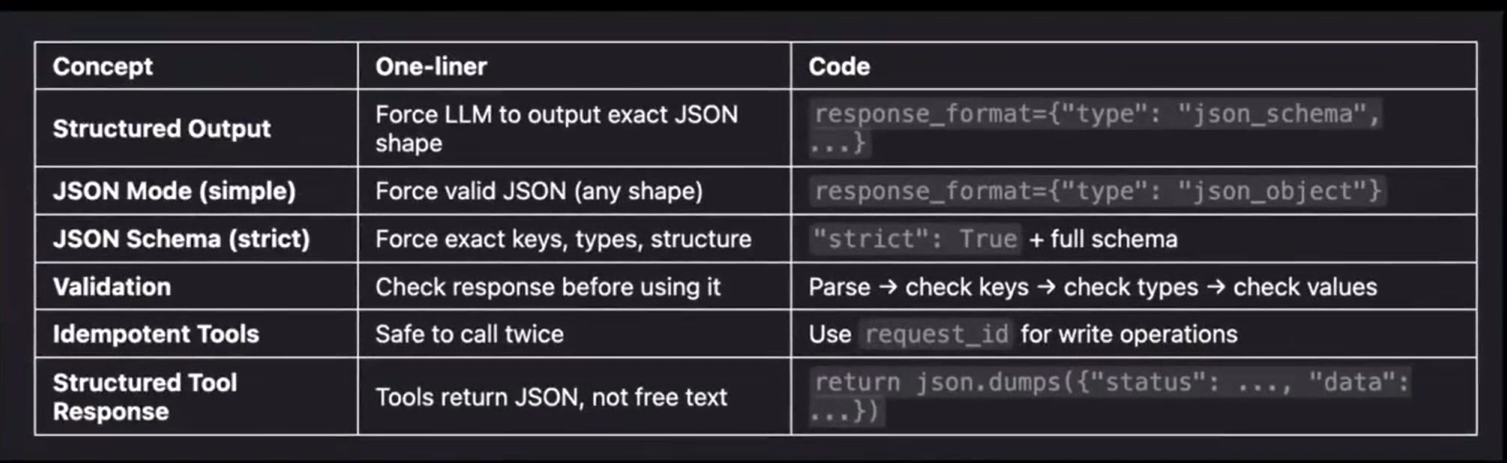

This entire process flow:
Tools creation -> Tools Defining for agents to use -> Wringting the agentic loop -> Defining the output format 
can be done simpy by using something called **"LangChain"**. LangChain is a framework that allows us to build applications with LLMs. It provides a simple and easy to use interface to create tools, define the output format, and write the agentic loop. It also provides a lot of other features like memory, caching, and more. 